# Feature Analysis
Analyse the 72 extracted features on labelled data (absent + present only).
Unknown is kept entirely separate, it is not analysed here.
Outputs: distribution plots, correlation heatmap, ranked feature list.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from pathlib import Path

PROJECT_ROOT  = Path(r"D:\sop")
FEATURES_DIR  = PROJECT_ROOT / "data" / "features"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({"font.size": 8})

print("Ready.")

Ready.


In [2]:
# load features and split into labelled (absent + present) and unknown

df_all      = pd.read_csv(FEATURES_DIR / "features.csv")
feat_cols   = [c for c in df_all.columns if c not in ["file", "class", "label"]]

df_labelled = df_all[df_all["class"].isin(["absent", "present"])].copy().reset_index(drop=True)
df_unknown  = df_all[df_all["class"] == "unknown"].copy().reset_index(drop=True)

print(f"Total files     : {len(df_all)}")
print(f"Labelled        : {len(df_labelled)}  (absent={len(df_labelled[df_labelled['class']=='absent'])}, present={len(df_labelled[df_labelled['class']=='present'])})")
print(f"Unknown (held)  : {len(df_unknown)}  : not used in this analysis")
print(f"Feature columns : {len(feat_cols)}")

Total files     : 7173
Labelled        : 4782  (absent=2391, present=2391)
Unknown (held)  : 2391  : not used in this analysis
Feature columns : 72


In [3]:
# outlier audit on labelled data
# for each feature: flag values beyond 5 std from the mean
# prints the feature, how many outliers, and the top 3 worst offenders

print("Outlier audit (values beyond 5 std from mean):\n")

outlier_summary = []

for col in feat_cols:
    vals  = df_labelled[col]
    mean  = vals.mean()
    std   = vals.std()
    if std == 0:
        continue
    z     = np.abs((vals - mean) / std)
    mask  = z > 5
    count = mask.sum()
    if count > 0:
        top   = df_labelled[mask].nlargest(3, col)[["file", "class", col]]
        outlier_summary.append({"feature": col, "outlier_count": count, "max_value": vals.max(), "max_z": z.max()})
        print(f"  {col}: {count} outliers  |  max={vals.max():.4f}  z={z.max():.1f}")
        print(top.to_string(index=False))
        print()

if not outlier_summary:
    print("  No outliers beyond 5 std found.")

outlier_df = pd.DataFrame(outlier_summary)
if len(outlier_df):
    outlier_df.to_csv(FEATURES_DIR / "outlier_audit.csv", index=False)
    print(f"Saved: {FEATURES_DIR / 'outlier_audit.csv'}")

Outlier audit (values beyond 5 std from mean):

  u1_mean: 20 outliers  |  max=0.0000  z=43.0
                      file   class  u1_mean
         p14_PV_decomposed present 0.000025
p35_MV_gauss980_decomposed present 0.000012
 p7_PV_gauss535_decomposed present 0.000009

  u1_var: 25 outliers  |  max=0.0114  z=14.5
                        file   class   u1_var
  p120_TV_gauss81_decomposed present 0.011399
 p120_TV_gauss697_decomposed present 0.011249
p120_TV_gauss1313_decomposed present 0.011124

  u1_rms: 12 outliers  |  max=0.1068  z=7.5
                        file   class   u1_rms
  p120_TV_gauss81_decomposed present 0.106764
 p120_TV_gauss697_decomposed present 0.106062
p120_TV_gauss1313_decomposed present 0.105470

  u1_zcr: 12 outliers  |  max=0.5843  z=8.2
              file  class   u1_zcr
a378_PV_decomposed absent 0.584330
 a46_MV_decomposed absent 0.545970
a333_AV_decomposed absent 0.496946

  u1_skew: 42 outliers  |  max=2.1516  z=13.5
                       file   class  u1

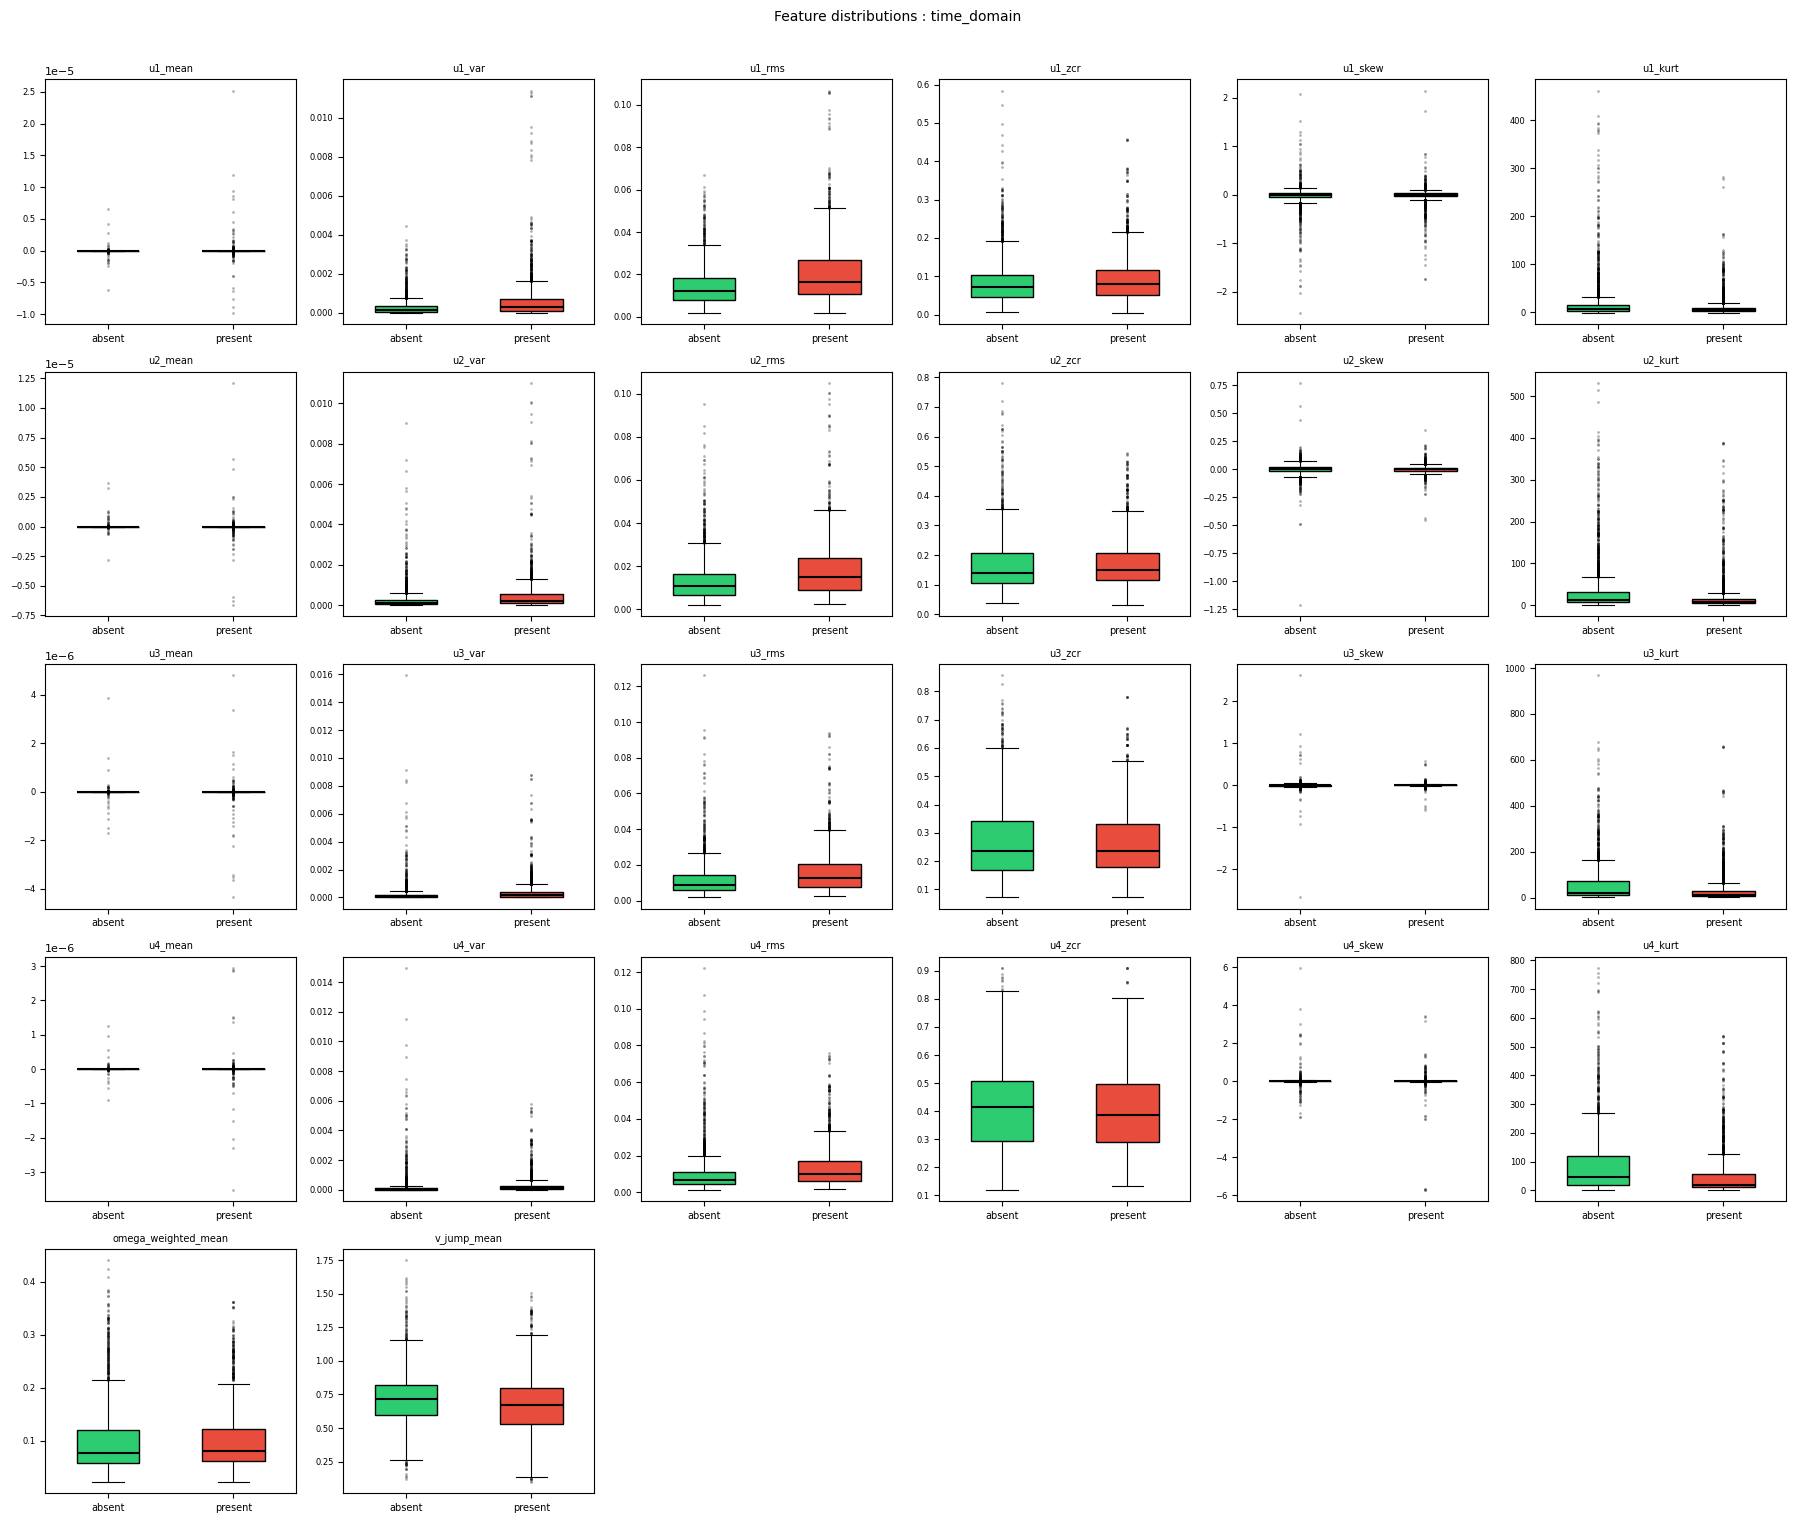

Saved: D:\sop\outputs\feature_dist_time_domain.png


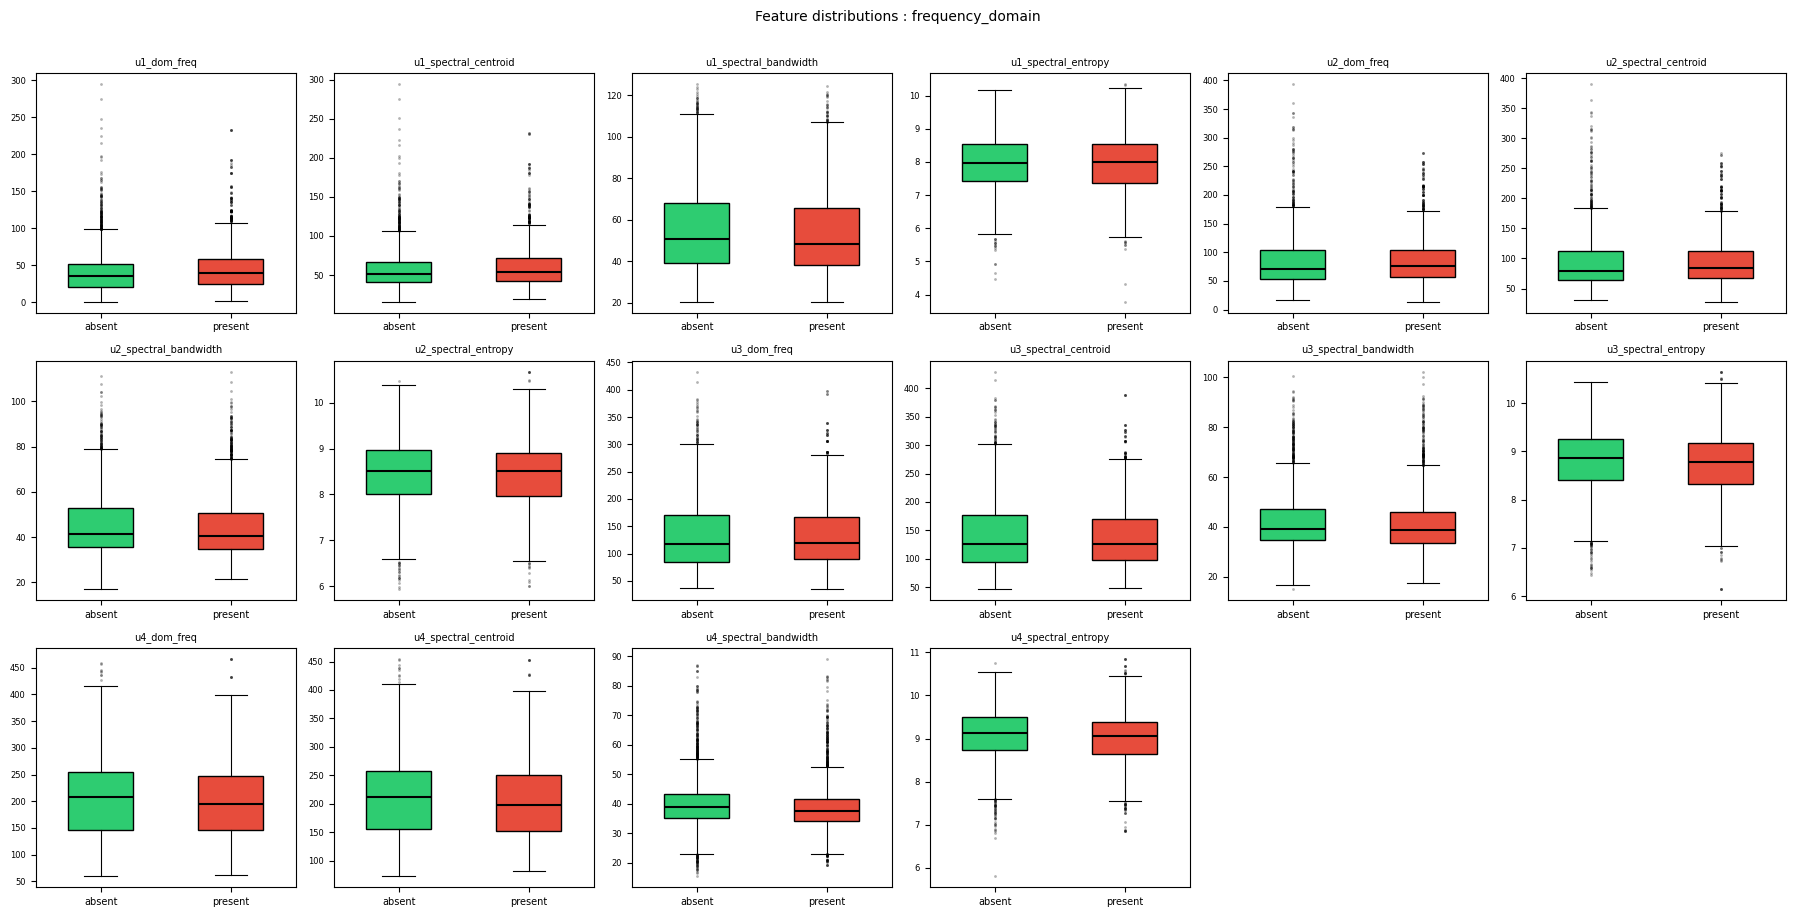

Saved: D:\sop\outputs\feature_dist_frequency_domain.png


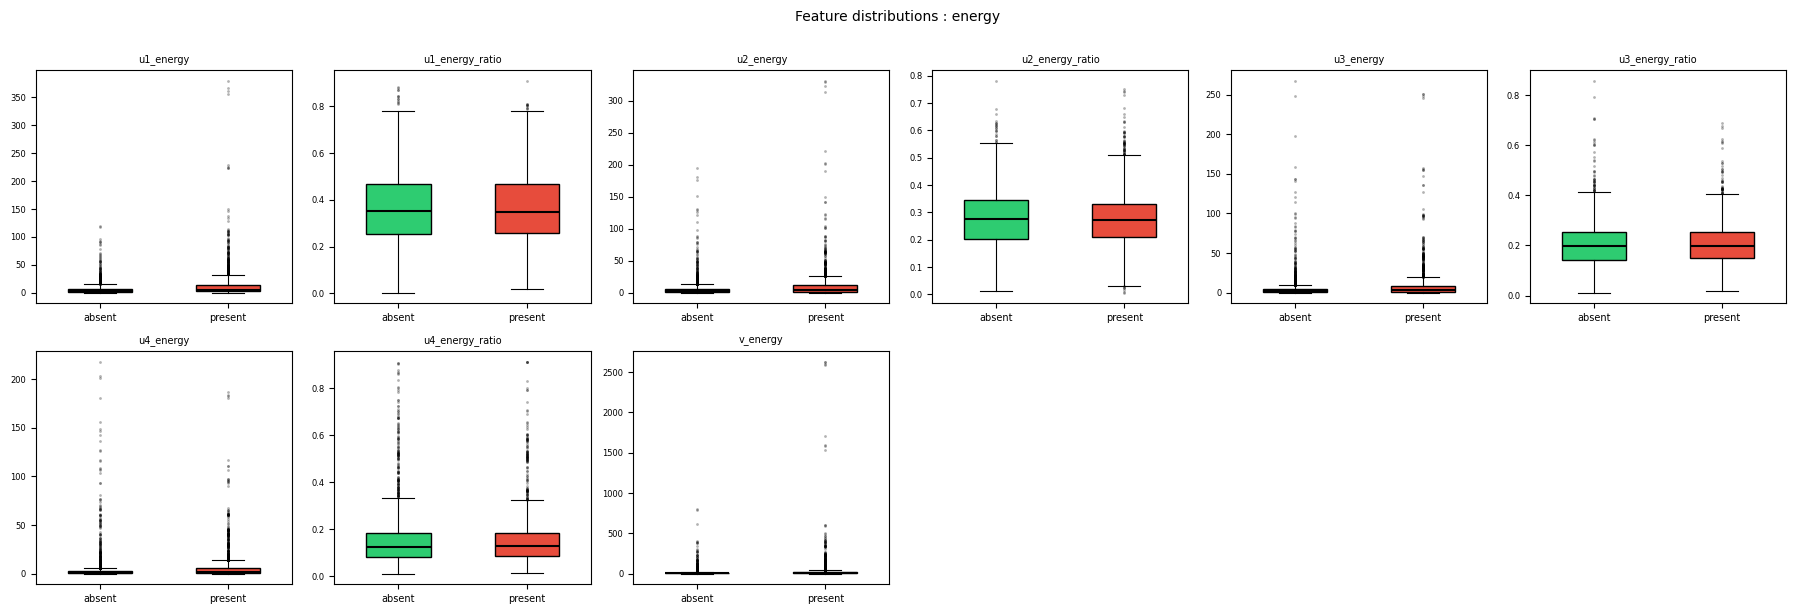

Saved: D:\sop\outputs\feature_dist_energy.png


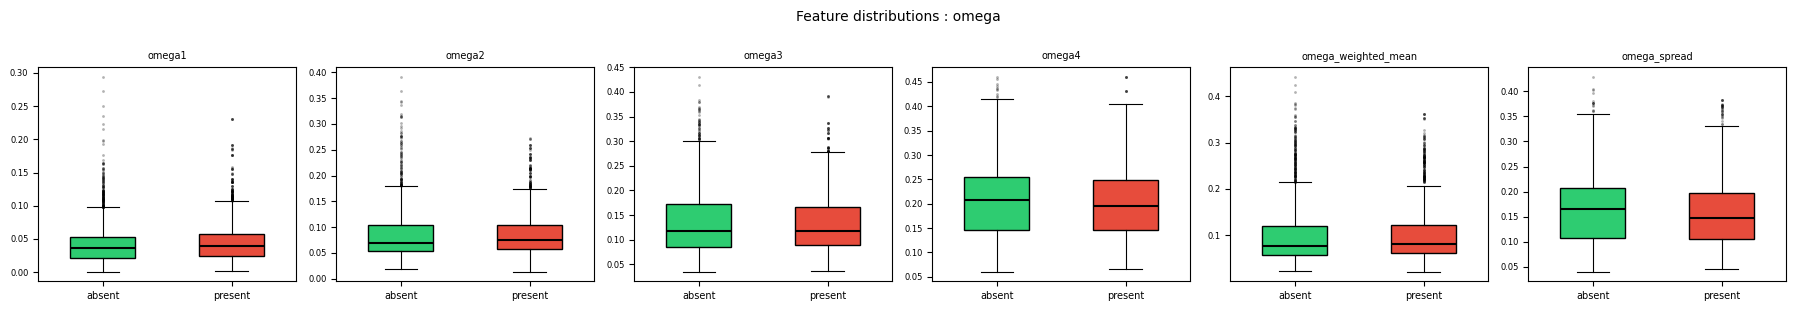

Saved: D:\sop\outputs\feature_dist_omega.png


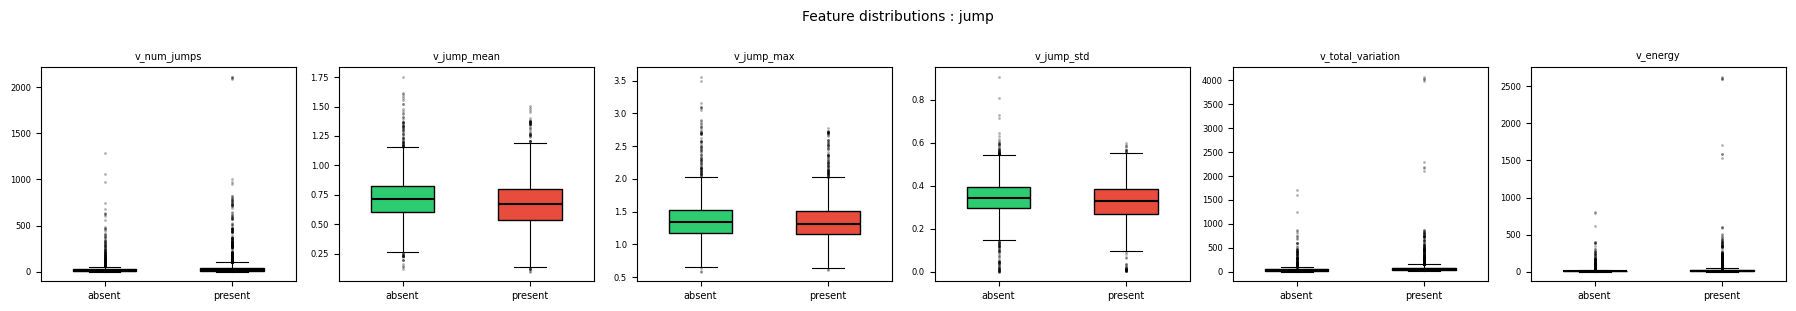

Saved: D:\sop\outputs\feature_dist_jump.png


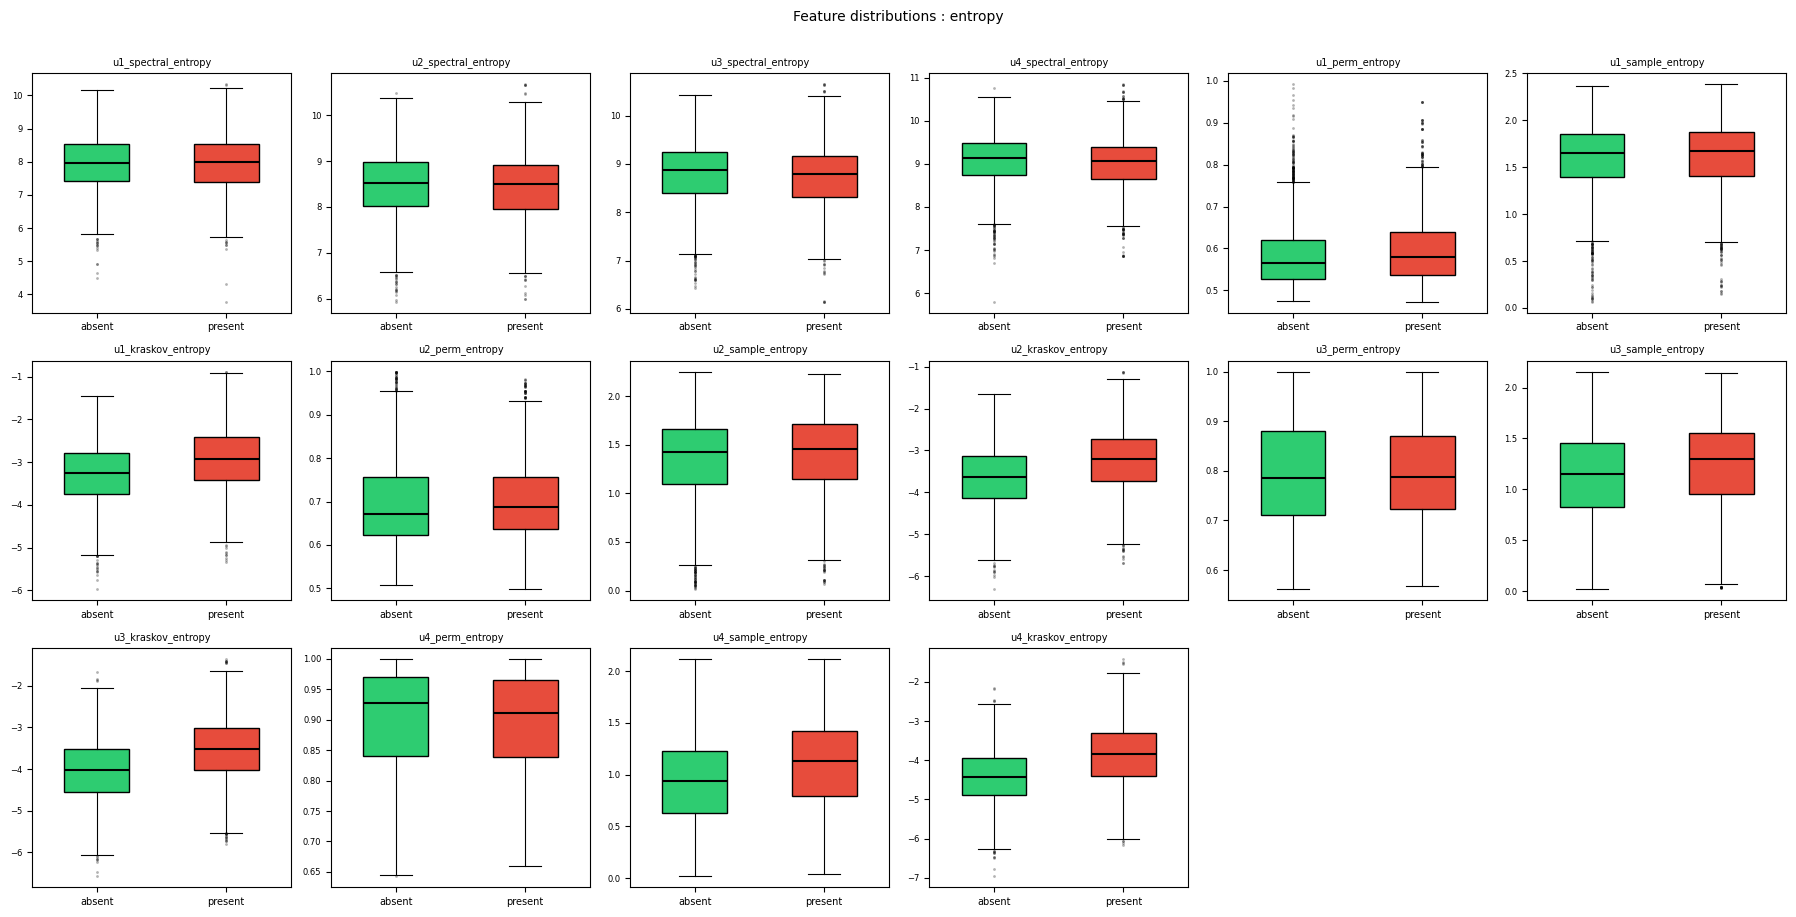

Saved: D:\sop\outputs\feature_dist_entropy.png


In [4]:
# feature distributions by class, boxplots grouped by feature family
# one figure per group, saved separately for clarity

absent_df  = df_labelled[df_labelled["class"] == "absent"]
present_df = df_labelled[df_labelled["class"] == "present"]

groups = {
    "time_domain"      : [c for c in feat_cols if any(c.endswith(s) for s in ["_mean","_var","_rms","_zcr","_skew","_kurt"])],
    "frequency_domain" : [c for c in feat_cols if any(c.endswith(s) for s in ["_dom_freq","_spectral_centroid","_spectral_bandwidth","_spectral_entropy"])],
    "energy"           : [c for c in feat_cols if any(c.endswith(s) for s in ["_energy","_energy_ratio"])],
    "omega"            : [c for c in feat_cols if c.startswith("omega")],
    "jump"             : [c for c in feat_cols if c.startswith("v_")],
    "entropy"          : [c for c in feat_cols if c.endswith("_entropy")],
}

colors = {"absent": "#2ecc71", "present": "#e74c3c"}

for group_name, cols in groups.items():
    if not cols:
        print(f"Skipping {group_name} : no matching features found.")
        continue
    n     = len(cols)
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        ax   = axes[i]
        data = [absent_df[col].values, present_df[col].values]
        bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                          medianprops=dict(color="black", linewidth=1.5),
                          whiskerprops=dict(linewidth=0.8),
                          capprops=dict(linewidth=0.8),
                          flierprops=dict(marker=".", markersize=2, alpha=0.3))
        bp["boxes"][0].set_facecolor(colors["absent"])
        bp["boxes"][1].set_facecolor(colors["present"])
        ax.set_title(col, fontsize=7)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["absent", "present"], fontsize=7)
        ax.tick_params(axis="y", labelsize=6)

    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Feature distributions : {group_name}", fontsize=10, y=1.01)
    plt.tight_layout()
    out = OUTPUTS_DIR / f"feature_dist_{group_name}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

Saved: D:\sop\data\features\feature_correlations.csv


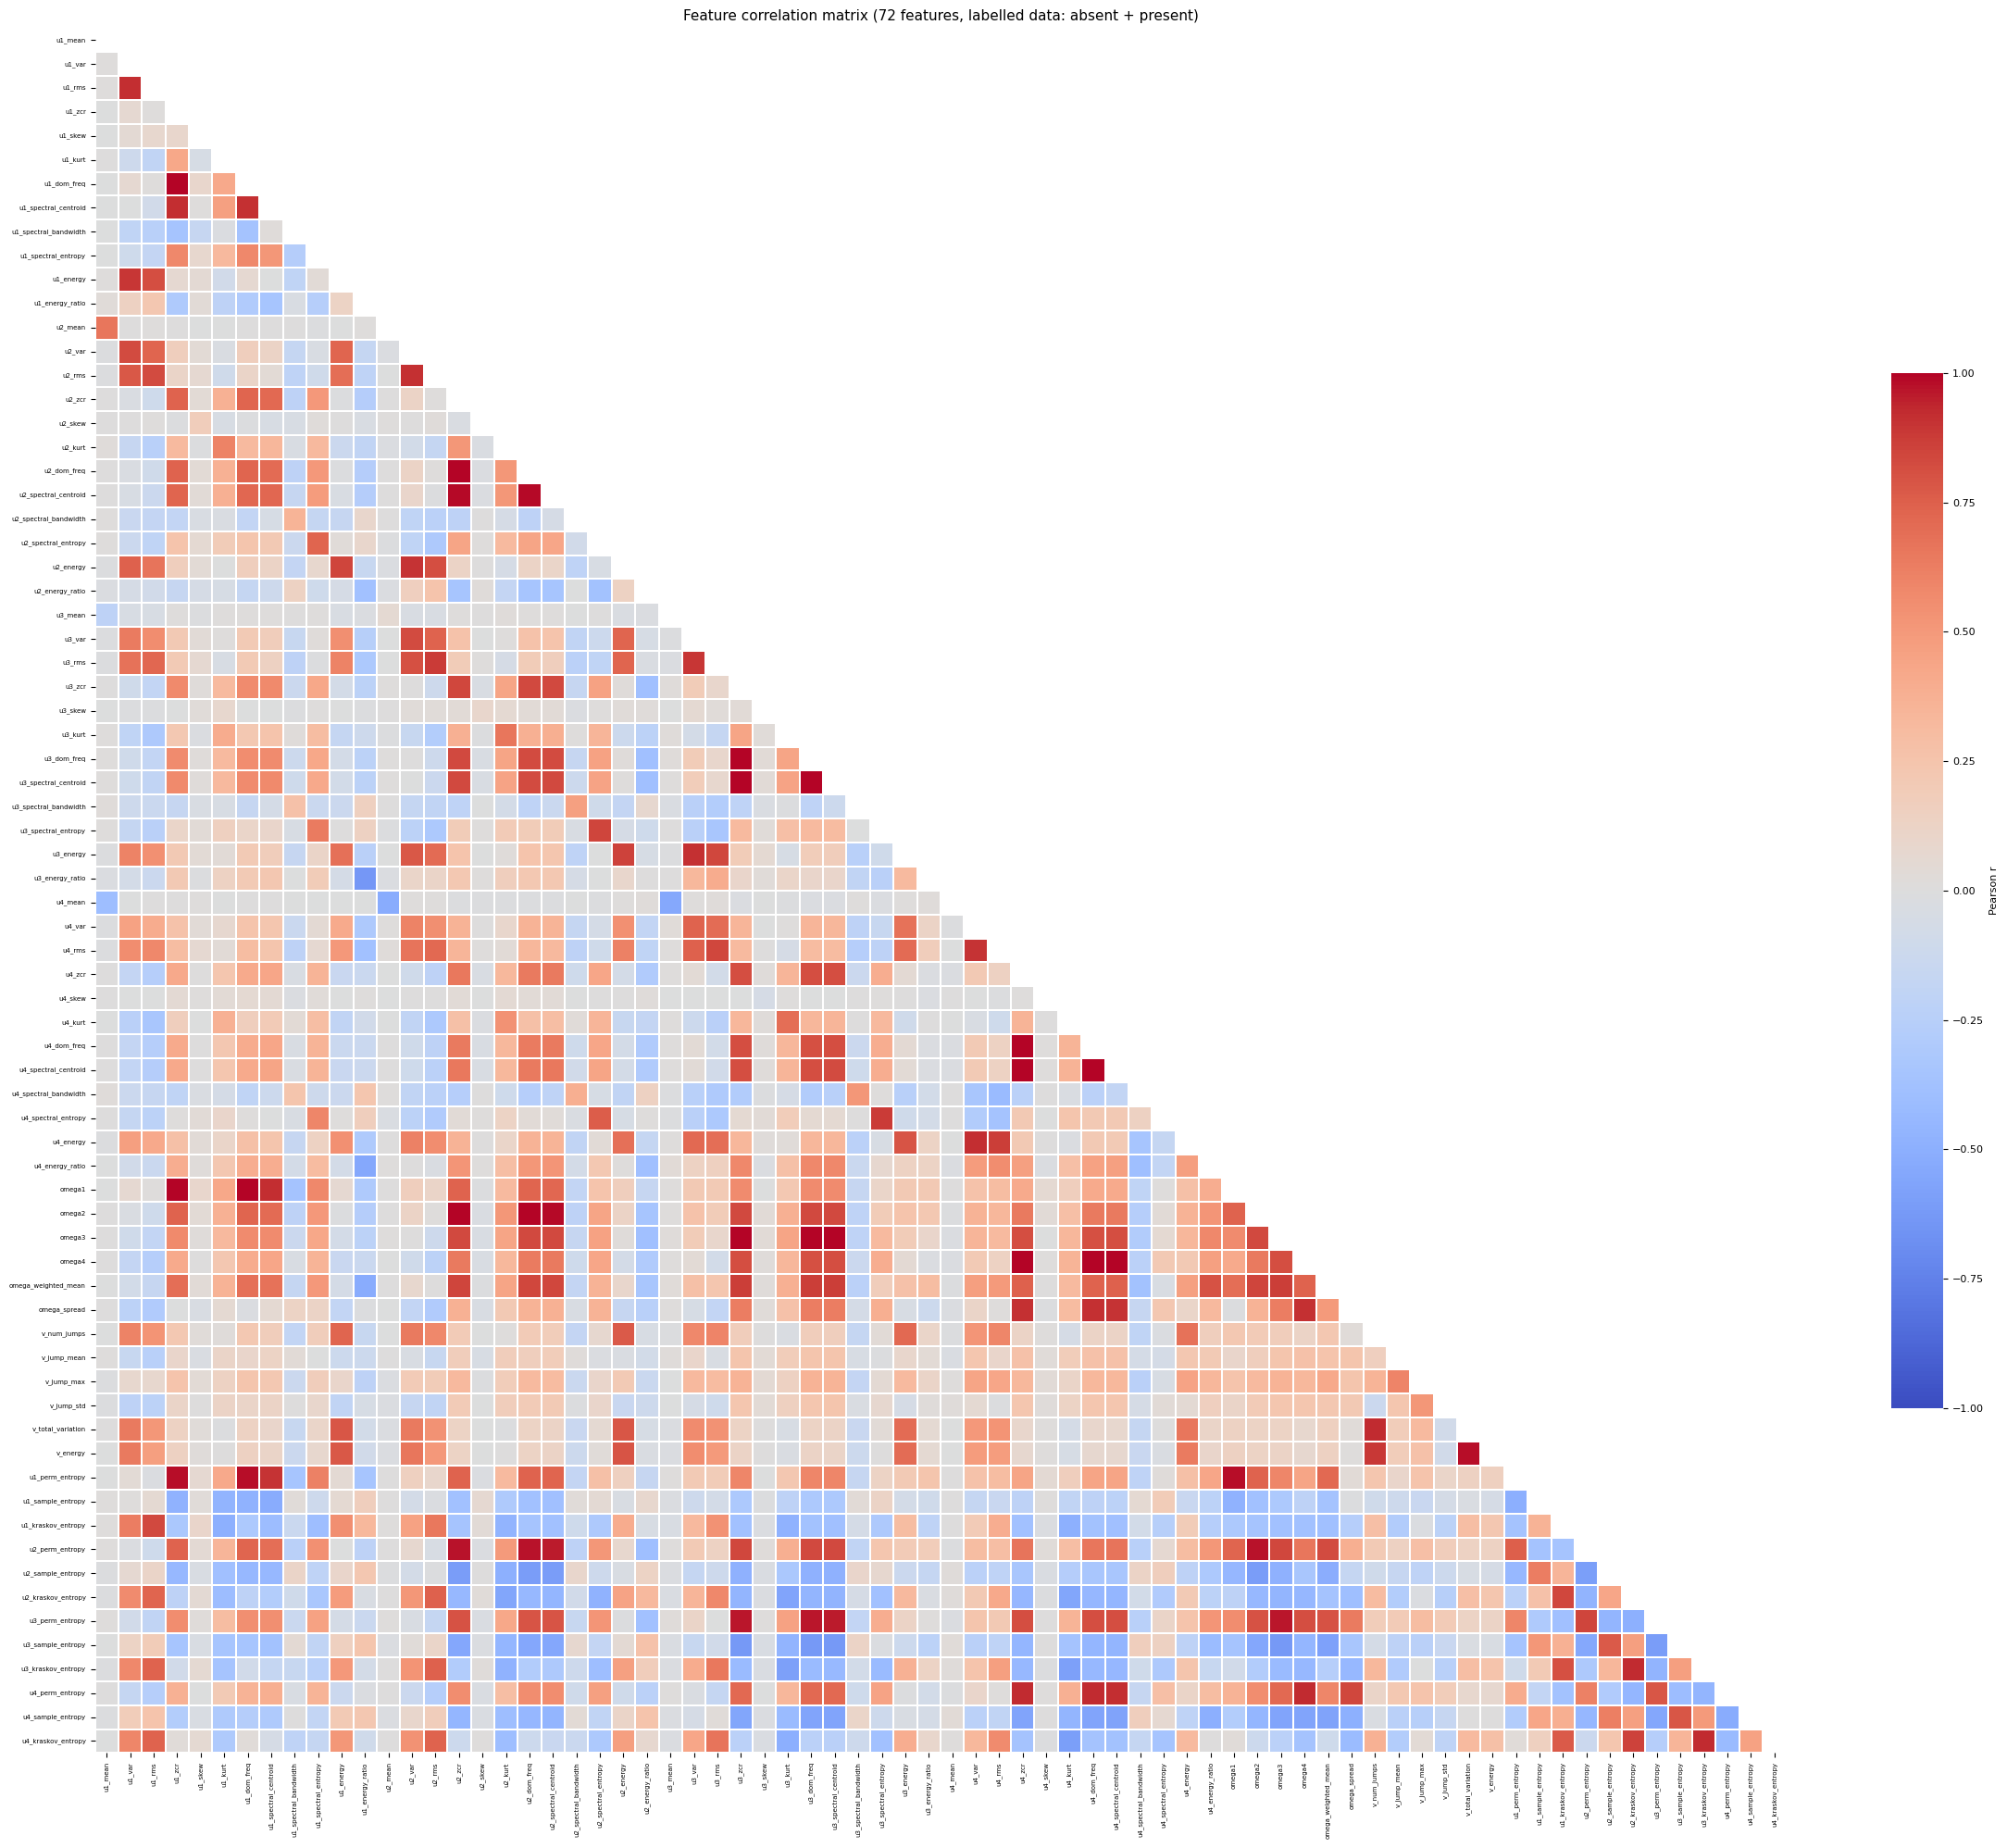

Saved: D:\sop\outputs\feature_correlation_heatmap.png

Highly correlated pairs (|r| > 0.95):
  u1_zcr  <->  u1_dom_freq  r=0.9978
  u1_zcr  <->  omega1  r=0.9995
  u1_zcr  <->  u1_perm_entropy  r=0.9808
  u1_dom_freq  <->  omega1  r=0.9982
  u1_dom_freq  <->  u1_perm_entropy  r=0.9772
  u2_zcr  <->  u2_dom_freq  r=0.9987
  u2_zcr  <->  u2_spectral_centroid  r=0.9866
  u2_zcr  <->  omega2  r=0.9998
  u2_zcr  <->  u2_perm_entropy  r=0.9751
  u2_dom_freq  <->  u2_spectral_centroid  r=0.9851
  u2_dom_freq  <->  omega2  r=0.9988
  u2_dom_freq  <->  u2_perm_entropy  r=0.9741
  u2_spectral_centroid  <->  omega2  r=0.9867
  u2_spectral_centroid  <->  u2_perm_entropy  r=0.9566
  u3_zcr  <->  u3_dom_freq  r=0.9991
  u3_zcr  <->  u3_spectral_centroid  r=0.9955
  u3_zcr  <->  omega3  r=0.9999
  u3_zcr  <->  u3_perm_entropy  r=0.9651
  u3_dom_freq  <->  u3_spectral_centroid  r=0.9946
  u3_dom_freq  <->  omega3  r=0.9992
  u3_dom_freq  <->  u3_perm_entropy  r=0.9645
  u3_spectral_centroid  <->  omeg

In [5]:
# correlation matrix + heatmap on labelled data
# saves both the raw correlation csv and the heatmap png

corr_matrix = df_labelled[feat_cols].corr(method="pearson")
corr_matrix.to_csv(FEATURES_DIR / "feature_correlations.csv")
print(f"Saved: {FEATURES_DIR / 'feature_correlations.csv'}")

n_feat = len(feat_cols)
fig, ax = plt.subplots(figsize=(24, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.2,
    linecolor="white",
    annot=False,
    ax=ax,
    cbar_kws={"shrink": 0.6, "label": "Pearson r"}
)
ax.set_title(f"Feature correlation matrix ({n_feat} features, labelled data: absent + present)", fontsize=11)
ax.tick_params(axis="x", labelsize=5, rotation=90)
ax.tick_params(axis="y", labelsize=5, rotation=0)
plt.tight_layout()
out = OUTPUTS_DIR / "feature_correlation_heatmap.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

# print pairs with |r| > 0.95 , highly redundant features
print("\nHighly correlated pairs (|r| > 0.95):")
pairs = []
for i in range(len(feat_cols)):
    for j in range(i + 1, len(feat_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.95:
            pairs.append((feat_cols[i], feat_cols[j], round(r, 4)))
            print(f"  {feat_cols[i]}  <->  {feat_cols[j]}  r={r:.4f}")
if not pairs:
    print("  None found.")

In [6]:
# Mann-Whitney U test: rank all 60 features by how well they separate absent vs present
# Mann-Whitney is non-parametric , no assumption of normality, robust to outliers
# p-value: probability the two distributions are the same (lower = better separation)
# effect size (r = Z / sqrt(N)): standardised measure of separation strength

absent_vals  = df_labelled[df_labelled["class"] == "absent"]
present_vals = df_labelled[df_labelled["class"] == "present"]
N            = len(df_labelled)

rankings = []

for col in feat_cols:
    a = absent_vals[col].values
    p = present_vals[col].values
    u_stat, p_val = stats.mannwhitneyu(a, p, alternative="two-sided")
    # effect size r = Z / sqrt(N), where Z is normal approximation of U
    z        = (u_stat - (len(a) * len(p) / 2)) / np.sqrt(len(a) * len(p) * (len(a) + len(p) + 1) / 12)
    effect_r = abs(z) / np.sqrt(N)
    rankings.append({
        "feature"   : col,
        "u_stat"    : round(u_stat, 2),
        "p_value"   : p_val,
        "effect_r"  : round(effect_r, 4),
        "mean_absent" : round(a.mean(), 6),
        "mean_present": round(p.mean(), 6),
    })

rankings_df = rankings_df = pd.DataFrame(rankings).sort_values("effect_r", ascending=False).reset_index(drop=True)
rankings_df.to_csv(FEATURES_DIR / "feature_rankings.csv", index=False)

print("Top 20 features by separation strength (effect size r):\n")
print(rankings_df.head(20).to_string(index=False))
print(f"\nSaved: {FEATURES_DIR / 'feature_rankings.csv'}")

Top 20 features by separation strength (effect size r):

           feature    u_stat       p_value  effect_r  mean_absent  mean_present
u4_kraskov_entropy 1688507.0 1.190519e-132    0.3544    -4.426369     -3.857600
u3_kraskov_entropy 1807842.0 2.369055e-107    0.3183    -4.047144     -3.533896
           u4_kurt 3754436.0  1.326511e-78    0.2714    86.866016     50.753283
u2_kraskov_entropy 1965753.0  4.877223e-78    0.2704    -3.668605     -3.246269
           u3_kurt 3664063.0  6.657091e-64    0.2441    58.170438     34.862776
u1_kraskov_entropy 2062952.0  2.371308e-62    0.2410    -3.297828     -2.933643
            u1_var 2074007.0  1.110375e-60    0.2376     0.000291      0.000597
            u1_rms 2074007.0  1.110375e-60    0.2376     0.014461      0.020293
            u3_rms 2086249.0  7.383035e-59    0.2339     0.011736      0.015831
            u3_var 2086249.0  7.383035e-59    0.2339     0.000239      0.000386
            u4_var 2087369.0  1.080378e-58    0.2336     0.0002

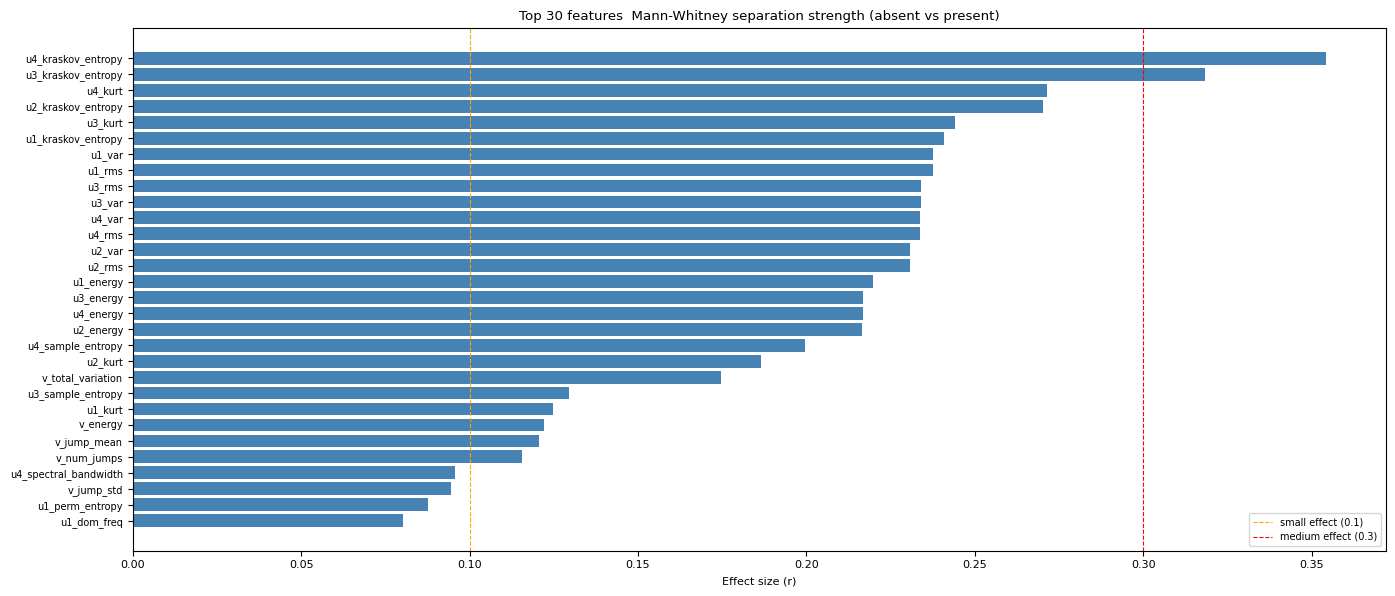

Saved: D:\sop\outputs\feature_rankings_top30.png


In [7]:
# bar chart of top 30 features by effect size
# gives a quick visual of which features matter most

top30 = rankings_df.head(30)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top30["feature"][::-1], top30["effect_r"][::-1], color="steelblue", edgecolor="none")
ax.set_xlabel("Effect size (r)")
ax.set_title("Top 30 features  Mann-Whitney separation strength (absent vs present)")
ax.tick_params(axis="y", labelsize=7)
ax.axvline(0.1, color="orange", linewidth=0.8, linestyle="--", label="small effect (0.1)")
ax.axvline(0.3, color="red",  linewidth=0.8, linestyle="--", label="medium effect (0.3)")
ax.legend(fontsize=7)
plt.tight_layout()
out = OUTPUTS_DIR / "feature_rankings_top30.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

In [8]:
# summary of all saved outputs

print("All outputs saved:")
for f in sorted(FEATURES_DIR.glob("*.csv")):
    print(f"  {f}")
for f in sorted(OUTPUTS_DIR.glob("feature_*.png")):
    print(f"  {f}")

All outputs saved:
  D:\sop\data\features\feature_correlations.csv
  D:\sop\data\features\feature_rankings.csv
  D:\sop\data\features\features.csv
  D:\sop\data\features\features_entropy.csv
  D:\sop\data\features\features_selected.csv
  D:\sop\data\features\features_selected_unknown.csv
  D:\sop\data\features\outlier_audit.csv
  D:\sop\outputs\feature_correlation_heatmap.png
  D:\sop\outputs\feature_dist_energy.png
  D:\sop\outputs\feature_dist_entropy.png
  D:\sop\outputs\feature_dist_frequency_domain.png
  D:\sop\outputs\feature_dist_jump.png
  D:\sop\outputs\feature_dist_omega.png
  D:\sop\outputs\feature_dist_time_domain.png
  D:\sop\outputs\feature_rankings_top30.png
